# **Work and Occupation Analysis:**

In [36]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings 
warnings.filterwarnings('ignore')

In [37]:
data= pd.read_csv('data.csv')

In [38]:
data.shape

(42468, 14)

In [39]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [40]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


### **1. Workclass Frequency:**

In [41]:
daa= data['workclass'].value_counts().reset_index(name= "Counts")
daa

,workclass,Counts
0,Private,28312
1,Self-emp-not-inc,3735
2,Local-gov,3011
3,Others,2411
4,State-gov,1927
5,Self-emp-inc,1644
6,Federal-gov,1397
7,Without-pay,21
8,Never-worked,10


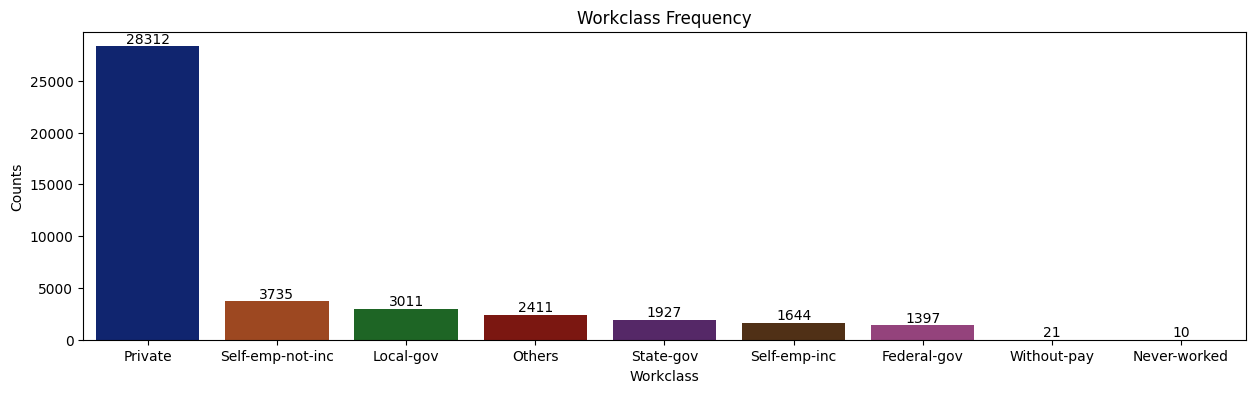

In [42]:
plt.figure(figsize=(15, 4))
sns.barplot(data= daa, x= 'workclass', y= 'Counts', palette= "dark", hue= "workclass")
# add annotations
for i, v in enumerate(daa['Counts']):
    plt.text(x= i, y= v, s= str(v), ha='center', va='bottom')
plt.title("Workclass Frequency")
plt.xlabel("Workclass")
plt.ylabel("Counts")
plt.show()

---
---
----

### **2. Average Salary by Workclass:**

In [43]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [44]:
data["workclass"].unique()

array(['Private', 'Local-gov', 'Others', 'Self-emp-not-inc',
       'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay',
       'Never-worked'], dtype=object)

In [45]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [46]:
data.groupby("workclass")["salary"].value_counts().reset_index(name= "Counts")

,workclass,salary,Counts
0,Federal-gov,<=50K,858
1,Federal-gov,>50K,539
2,Local-gov,<=50K,2126
3,Local-gov,>50K,885
4,Never-worked,<=50K,10
5,Others,<=50K,2150
6,Others,>50K,261
7,Private,<=50K,22022
8,Private,>50K,6290
9,Self-emp-inc,>50K,901


There, is workclass named `"Without-pay"`, ie. it belongs to a class where there no pay-check for the work. But here see, there are 21 instances of `without-pay` but they are actually salaried. This is probably because of data entry errors. Lets fix this:

In [47]:
data.loc[data["workclass"] == "Without-pay", "salary"] = "no_pay"

In [48]:
data["salary"].unique()

array(['<=50K', '>50K', 'no_pay'], dtype=object)

In [49]:
daa= data.groupby("workclass")["salary"].value_counts().reset_index(name= "Counts")
daa

,workclass,salary,Counts
0,Federal-gov,<=50K,858
1,Federal-gov,>50K,539
2,Local-gov,<=50K,2126
3,Local-gov,>50K,885
4,Never-worked,<=50K,10
5,Others,<=50K,2150
6,Others,>50K,261
7,Private,<=50K,22022
8,Private,>50K,6290
9,Self-emp-inc,>50K,901


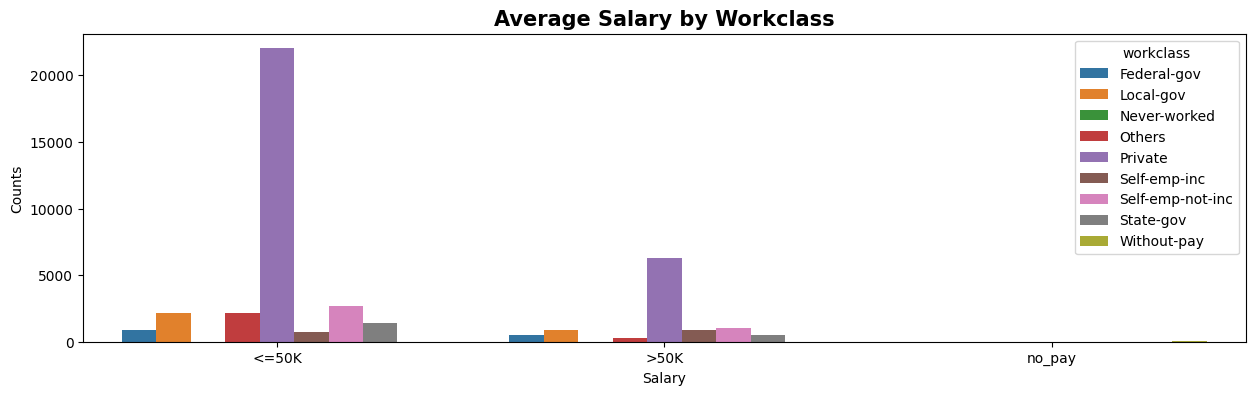

In [50]:
plt.figure(figsize=(15, 4))
sns.barplot(data= daa, x= "salary", y= "Counts", hue= "workclass")
plt.xlabel("Salary")
plt.ylabel("Counts")
plt.title("Average Salary by Workclass", fontsize= 15, fontweight= "bold")
plt.show()

Majority of people have salary less then 50k and among them, Private jobclass accounts the most.For salary less then and greater than 50k private workclass accounts the most. 

----------------
-------
------
----
-----
------

### **3. Occupation Frequency:**

In [51]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [52]:
data["occupation"].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Others', 'Other-service', 'Prof-specialty', 'Craft-repair',
       'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales',
       'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners',
       'Armed-Forces'], dtype=object)

`Others` and `Other-service` are same things. Lets use `Others` for both of these cases:

In [53]:
data["occupation"]= data["occupation"].replace("Other-service", "Others")

In [54]:
data["occupation"].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Others', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [55]:
oo= data.groupby(by= "occupation")["occupation"].value_counts().reset_index(name= "Counts").sort_values(by= "Counts", ascending= False)
oo

,occupation,Counts
7,Others,6787
9,Prof-specialty,5679
3,Exec-managerial,5412
0,Adm-clerical,4813
11,Sales,4766
2,Craft-repair,4726
6,Machine-op-inspct,2492
13,Transport-moving,2071
5,Handlers-cleaners,1738
4,Farming-fishing,1434


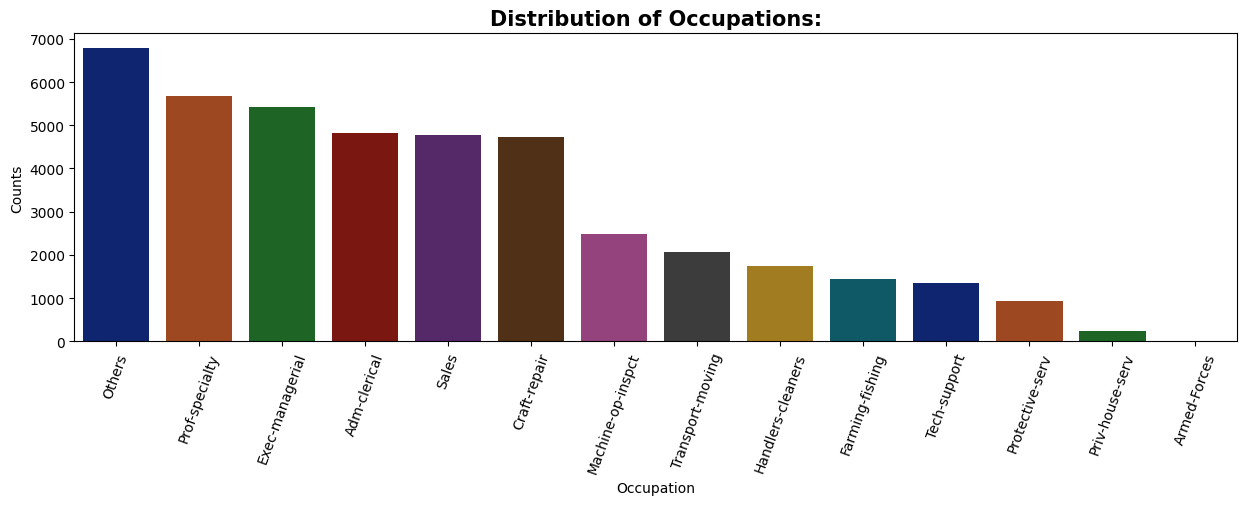

In [56]:
plt.figure(figsize=(15, 4))
sns.barplot(data= oo, x= "occupation", y= "Counts", palette= "dark", hue= "occupation")
plt.xticks(rotation= 70)
plt.title("Distribution of Occupations:", fontsize= 15, fontweight= "bold")
plt.xlabel("Occupation")
plt.ylabel("Counts")
plt.show()

---
----
----
----
----

### **4. Income Level by Occupation:**

In [57]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [58]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [59]:
occ= data.groupby(by= "occupation")["salary"].value_counts().reset_index(name= "No. of People") 
occ

,occupation,salary,No. of People
0,Adm-clerical,<=50K,4090
1,Adm-clerical,>50K,720
2,Adm-clerical,no_pay,3
3,Armed-Forces,<=50K,10
4,Armed-Forces,>50K,5
5,Craft-repair,<=50K,3621
6,Craft-repair,>50K,1104
7,Craft-repair,no_pay,1
8,Exec-managerial,<=50K,2882
9,Exec-managerial,>50K,2529


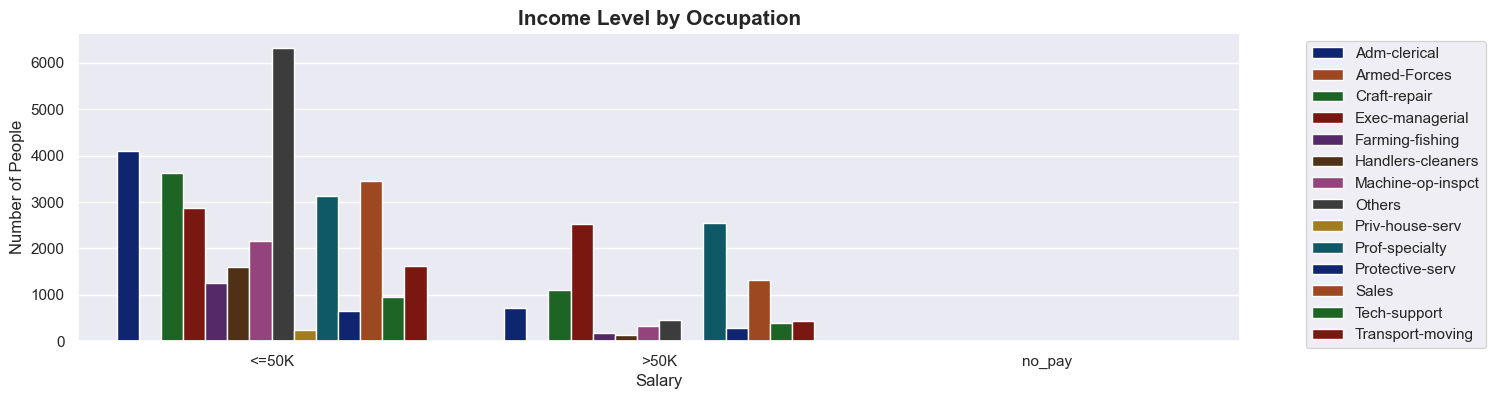

In [60]:
plt.figure(figsize=(15, 4))
sns.set_theme(style= "darkgrid")
sns.barplot(data= occ, hue= "occupation", y= "No. of People", x= "salary", palette= "dark")
plt.legend(bbox_to_anchor= (1.05, 1), loc= "upper left")
plt.title("Income Level by Occupation", fontsize= 15, fontweight= "bold")
plt.xlabel("Salary")
plt.ylabel("Number of People")
plt.show()

The bar chart depicts the distribution of income levels across various occupations. A significant number of people in "Adm-clerical" and "Sales" occupations earn less than or equal to $50,000, while "Tech-support" and "Transport moving" show a more balanced distribution between income levels. Conversely, "Armed-Forces" and "Exec-managerial" occupations have higher counts in the ">50K" category, indicating that these roles tend to yield higher salaries. Overall, the data highlights disparities in income levels based on occupation.

---
---
---


### **5. Hours Worked per Week by Occupation:**

In [61]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [65]:
data.head(2)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


In [ ]:
data["occupation"].unique() 

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Others', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [73]:
dass= data.groupby(by= "occupation")["hours-per-week"].agg(func= ["mean", "median"]).reset_index()
dass

,occupation,mean,median
0,Adm-clerical,37.726782,40.0
1,Armed-Forces,41.600000,40.0
2,Craft-repair,42.642404,40.0
3,Exec-managerial,45.083888,40.0
4,Farming-fishing,46.914226,40.0
5,Handlers-cleaners,38.212313,40.0
6,Machine-op-inspct,40.882825,40.0
7,Others,33.917931,40.0
8,Priv-house-serv,32.966667,35.0
9,Prof-specialty,42.338792,40.0


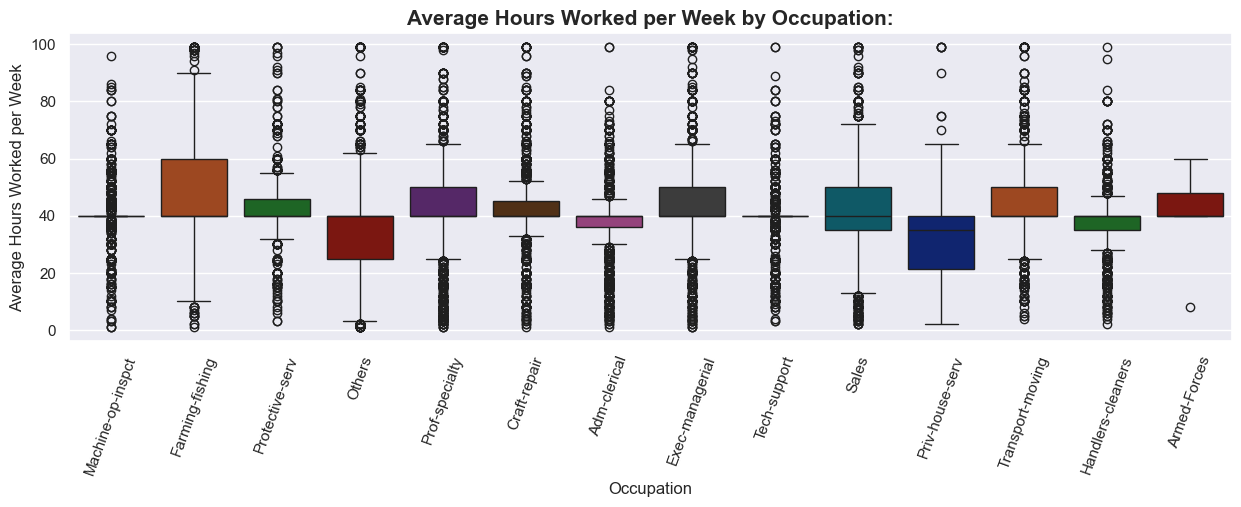

In [79]:
plt.figure(figsize=(15, 4))
sns.boxplot(data= data, x= "occupation", y= "hours-per-week" , palette= "dark")
plt.title("Average Hours Worked per Week by Occupation:", fontsize= 15, fontweight= "bold")
plt.xlabel("Occupation")
plt.ylabel("Average Hours Worked per Week")
plt.xticks(rotation= 70)
plt.show()

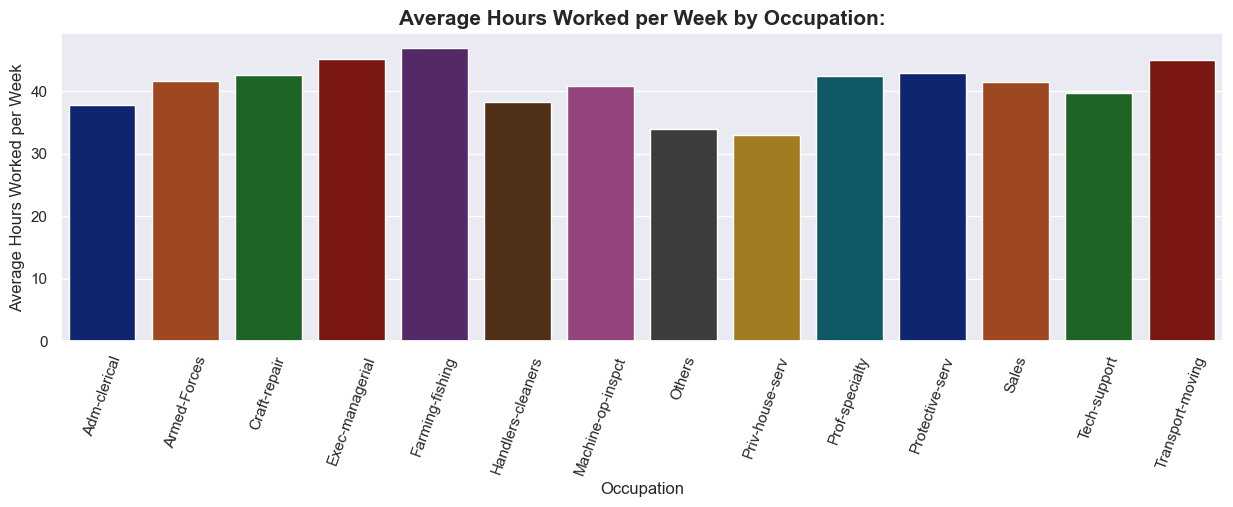

In [76]:
plt.figure(figsize=(15, 4))
sns.set_theme(style= "darkgrid")
sns.barplot(data= dass, x= "occupation", y= "mean", palette= "dark")
plt.title("Average Hours Worked per Week by Occupation:", fontsize= 15, fontweight= "bold")
plt.xlabel("Occupation")
plt.ylabel("Average Hours Worked per Week")
plt.xticks(rotation= 70)
plt.show()

### **6. Which `workclass` from what `occupation` works `longest hours per week`?**

In [80]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [81]:
data.head(2)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


In [82]:
data[["workclass", "occupation", "hours-per-week"]]

,workclass,occupation,hours-per-week
0,Private,Machine-op-inspct,40
1,Private,Farming-fishing,50
2,Local-gov,Protective-serv,40
3,Private,Machine-op-inspct,40
4,Others,Others,30
...,...,...,...
42463,Private,Exec-managerial,40
42464,Private,Protective-serv,40
42465,Private,Tech-support,38
42466,Private,Adm-clerical,40


In [94]:
wc= data.groupby(by= ["workclass", "occupation"])["hours-per-week"].value_counts().reset_index()
wc

,workclass,occupation,hours-per-week,count
0,Federal-gov,Adm-clerical,40,325
1,Federal-gov,Adm-clerical,45,18
2,Federal-gov,Adm-clerical,50,18
3,Federal-gov,Adm-clerical,20,13
4,Federal-gov,Adm-clerical,48,13
...,...,...,...,...
2186,Without-pay,Machine-op-inspct,40,1
2187,Without-pay,Others,10,1
2188,Without-pay,Others,55,1
2189,Without-pay,Sales,45,1


In [99]:
wc["workclass"].unique()

array(['Federal-gov', 'Local-gov', 'Never-worked', 'Others', 'Private',
       'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'],
      dtype=object)

In [ ]:
#Which `workclass` from what `occupation` works `longest hours per week`?
wc[wc["workclass"]== "Federal-gov"].sort_values(by= "hours-per-week", ascending= False).head(10)

,workclass,occupation,hours-per-week,count
112,Federal-gov,Prof-specialty,99,2
140,Federal-gov,Protective-serv,92,1
172,Federal-gov,Transport-moving,80,1
111,Federal-gov,Prof-specialty,80,2
19,Federal-gov,Adm-clerical,80,3
161,Federal-gov,Tech-support,75,1
130,Federal-gov,Protective-serv,72,3
99,Federal-gov,Others,72,1
125,Federal-gov,Prof-specialty,72,1
18,Federal-gov,Adm-clerical,72,3


In [103]:
# Which occupation of workclass= Federal-gov have largest number of workers and what is their 
# average weekly work hours:
wc[wc["workclass"]== "Federal-gov"].sort_values(by= "count", ascending= False).head(1)

,workclass,occupation,hours-per-week,count
0,Federal-gov,Adm-clerical,40,325


---
----
-----
-----
-----

### **7. People of which `workclass` from what `occupation` are the most laziest?**

In [105]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [114]:
data["workclass"].unique()

array(['Private', 'Local-gov', 'Others', 'Self-emp-not-inc',
       'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay',
       'Never-worked'], dtype=object)

In [122]:
aaa= data.sort_values(["workclass", "hours-per-week"], ascending=[True, False])[["workclass", "occupation", "hours-per-week"]]
aaa

,workclass,occupation,hours-per-week
8120,Federal-gov,Prof-specialty,99
32133,Federal-gov,Prof-specialty,99
2068,Federal-gov,Protective-serv,92
4521,Federal-gov,Adm-clerical,80
7098,Federal-gov,Prof-specialty,80
...,...,...,...
32406,Without-pay,Transport-moving,20
42230,Without-pay,Adm-clerical,16
39706,Without-pay,Adm-clerical,12
2910,Without-pay,Others,10


In [121]:
aaa[data["workclass"]== "Federal-gov"]

,workclass,occupation,hours-per-week
8120,Federal-gov,Prof-specialty,99
32133,Federal-gov,Prof-specialty,99
2068,Federal-gov,Protective-serv,92
4521,Federal-gov,Adm-clerical,80
7098,Federal-gov,Prof-specialty,80
...,...,...,...
42273,Federal-gov,Armed-Forces,8
38946,Federal-gov,Exec-managerial,6
13436,Federal-gov,Prof-specialty,5
4987,Federal-gov,Transport-moving,4


In [125]:
aaa[data["workclass"]== "Private"]

,workclass,occupation,hours-per-week
384,Private,Transport-moving,99
897,Private,Craft-repair,99
1634,Private,Transport-moving,99
2363,Private,Craft-repair,99
2982,Private,Transport-moving,99
...,...,...,...
10653,Private,Exec-managerial,1
25195,Private,Machine-op-inspct,1
32147,Private,Craft-repair,1
34764,Private,Machine-op-inspct,1


In [126]:
data["workclass"].unique()

array(['Private', 'Local-gov', 'Others', 'Self-emp-not-inc',
       'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay',
       'Never-worked'], dtype=object)

In [127]:
aaa[data["workclass"]== "Local-gov"]

,workclass,occupation,hours-per-week
1117,Local-gov,Prof-specialty,99
2651,Local-gov,Protective-serv,99
8932,Local-gov,Exec-managerial,99
33222,Local-gov,Craft-repair,99
37185,Local-gov,Protective-serv,99
...,...,...,...
38907,Local-gov,Craft-repair,5
24524,Local-gov,Prof-specialty,4
38405,Local-gov,Adm-clerical,4
2153,Local-gov,Exec-managerial,3


In [128]:
aaa[data["workclass"]== "Self-emp-not-inc"]

,workclass,occupation,hours-per-week
4974,Self-emp-not-inc,Farming-fishing,99
5797,Self-emp-not-inc,Prof-specialty,99
8343,Self-emp-not-inc,Farming-fishing,99
8355,Self-emp-not-inc,Adm-clerical,99
9714,Self-emp-not-inc,Adm-clerical,99
...,...,...,...
30358,Self-emp-not-inc,Prof-specialty,2
31810,Self-emp-not-inc,Prof-specialty,2
866,Self-emp-not-inc,Prof-specialty,1
33114,Self-emp-not-inc,Adm-clerical,1


In [129]:
aaa[data["workclass"]== "Federal-gov"]

,workclass,occupation,hours-per-week
8120,Federal-gov,Prof-specialty,99
32133,Federal-gov,Prof-specialty,99
2068,Federal-gov,Protective-serv,92
4521,Federal-gov,Adm-clerical,80
7098,Federal-gov,Prof-specialty,80
...,...,...,...
42273,Federal-gov,Armed-Forces,8
38946,Federal-gov,Exec-managerial,6
13436,Federal-gov,Prof-specialty,5
4987,Federal-gov,Transport-moving,4


In [130]:
aaa[data["workclass"]== "State-gov"]

,workclass,occupation,hours-per-week
2057,State-gov,Others,99
13727,State-gov,Prof-specialty,99
26318,State-gov,Prof-specialty,99
30391,State-gov,Exec-managerial,90
41728,State-gov,Prof-specialty,90
...,...,...,...
15873,State-gov,Adm-clerical,5
18566,State-gov,Prof-specialty,5
3664,State-gov,Prof-specialty,4
37606,State-gov,Craft-repair,4


**Accessing each group more professionally:**

1. **GroupBy and Iterate:**

We can loop through each group and access the sorted data for each `workclass`:

In [131]:
for workclass, group in aaa.groupby("workclass"):
    print(f"Workclass: {workclass}")
    display(group)

Workclass: Federal-gov


,workclass,occupation,hours-per-week
8120,Federal-gov,Prof-specialty,99
32133,Federal-gov,Prof-specialty,99
2068,Federal-gov,Protective-serv,92
4521,Federal-gov,Adm-clerical,80
7098,Federal-gov,Prof-specialty,80
...,...,...,...
42273,Federal-gov,Armed-Forces,8
38946,Federal-gov,Exec-managerial,6
13436,Federal-gov,Prof-specialty,5
4987,Federal-gov,Transport-moving,4


Workclass: Local-gov


,workclass,occupation,hours-per-week
1117,Local-gov,Prof-specialty,99
2651,Local-gov,Protective-serv,99
8932,Local-gov,Exec-managerial,99
33222,Local-gov,Craft-repair,99
37185,Local-gov,Protective-serv,99
...,...,...,...
38907,Local-gov,Craft-repair,5
24524,Local-gov,Prof-specialty,4
38405,Local-gov,Adm-clerical,4
2153,Local-gov,Exec-managerial,3


Workclass: Never-worked


...

,workclass,occupation,hours-per-week
4974,Self-emp-not-inc,Farming-fishing,99
5797,Self-emp-not-inc,Prof-specialty,99
8343,Self-emp-not-inc,Farming-fishing,99
8355,Self-emp-not-inc,Adm-clerical,99
9714,Self-emp-not-inc,Adm-clerical,99
...,...,...,...
30358,Self-emp-not-inc,Prof-specialty,2
31810,Self-emp-not-inc,Prof-specialty,2
866,Self-emp-not-inc,Prof-specialty,1
33114,Self-emp-not-inc,Adm-clerical,1


Workclass: State-gov


,workclass,occupation,hours-per-week
2057,State-gov,Others,99
13727,State-gov,Prof-specialty,99
26318,State-gov,Prof-specialty,99
30391,State-gov,Exec-managerial,90
41728,State-gov,Prof-specialty,90
...,...,...,...
15873,State-gov,Adm-clerical,5
18566,State-gov,Prof-specialty,5
3664,State-gov,Prof-specialty,4
37606,State-gov,Craft-repair,4


Workclass: Without-pay


,workclass,occupation,hours-per-week
36785,Without-pay,Farming-fishing,65
8569,Without-pay,Handlers-cleaners,60
38607,Without-pay,Others,55
16967,Without-pay,Farming-fishing,50
36073,Without-pay,Farming-fishing,50
6283,Without-pay,Sales,45
10170,Without-pay,Machine-op-inspct,40
13096,Without-pay,Exec-managerial,40
13271,Without-pay,Farming-fishing,40
28630,Without-pay,Craft-repair,40


2. **Create a Dictionary of DataFrames:**

This allows us to access each group easily by key:

In [132]:
workclass_groups = {k: v for k, v in aaa.groupby("workclass")}
# Example: access 'Private' workclass
workclass_groups["Private"]

,workclass,occupation,hours-per-week
384,Private,Transport-moving,99
897,Private,Craft-repair,99
1634,Private,Transport-moving,99
2363,Private,Craft-repair,99
2982,Private,Transport-moving,99
...,...,...,...
10653,Private,Exec-managerial,1
25195,Private,Machine-op-inspct,1
32147,Private,Craft-repair,1
34764,Private,Machine-op-inspct,1


3. **Pandas `groupby.get_group` (on demand):**

If you want to access a specific group:

In [133]:
grouped = aaa.groupby("workclass")
grouped.get_group("Private")

,workclass,occupation,hours-per-week
384,Private,Transport-moving,99
897,Private,Craft-repair,99
1634,Private,Transport-moving,99
2363,Private,Craft-repair,99
2982,Private,Transport-moving,99
...,...,...,...
10653,Private,Exec-managerial,1
25195,Private,Machine-op-inspct,1
32147,Private,Craft-repair,1
34764,Private,Machine-op-inspct,1
